#### Solve evolution equation of phi and background evolution simultaneously

In [1]:
import numpy as np, os
from matplotlib.pyplot import *

In [2]:
dir_evolver = '/global/homes/t/toshiyan/Work/Ongoing/rotation/code/phi-evolver/src/' # directory of pyrefCLASS
sys.path.append(dir_evolver)
from phi_evolver import evolver as evo

In [3]:
# Define constants (use Mpc unit)
h = 0.6736
omega_b = 0.02242
omega_cdm = 0.12
H0 = h*100
H0Mpc = H0/(3e+5)
Om = (omega_cdm + omega_b)/h**2
print(Om)

0.3138822986780711


In [4]:
dir_evolver = '/global/u1/t/toshiyan/Work/Ongoing/rotation/code/phi-evolver/'
dir_birefclass = '/global/u1/t/toshiyan/Work/Ongoing/rotation/code/birefclass_lens/'

In [5]:
logm = -30.5

In [8]:
a, phi, Ha, dHada = evo.compute_evolution(dir_evolver, dir_birefclass, 
                      logm, n=1, tf=100, xi = 1.1e-2, eps = 1e-8,
                      phi0_ini = 1, phi1_ini = 0,
                      h=h,omega_b=omega_b,omega_cdm=omega_cdm,
                    dir_output='./',)

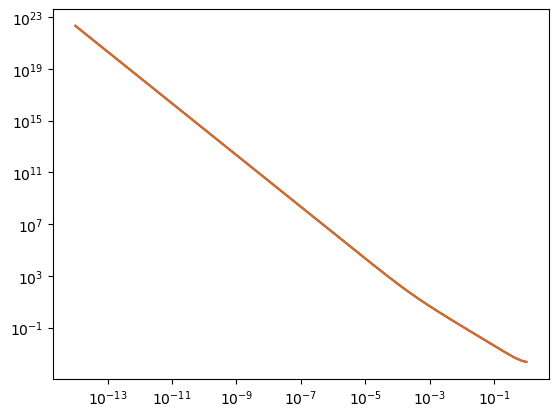

In [9]:
loglog(a,Ha(a))
loglog(a,H0Mpc*evo.E_a(a,Om))

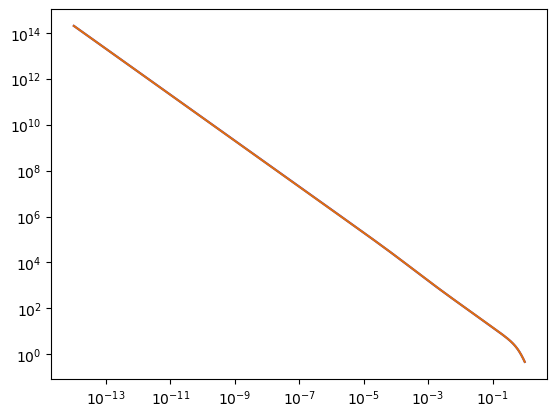

In [10]:
loglog(a,-dHada(a)/Ha(a))
loglog(a,-evo.dlnEa_da(a,Om))

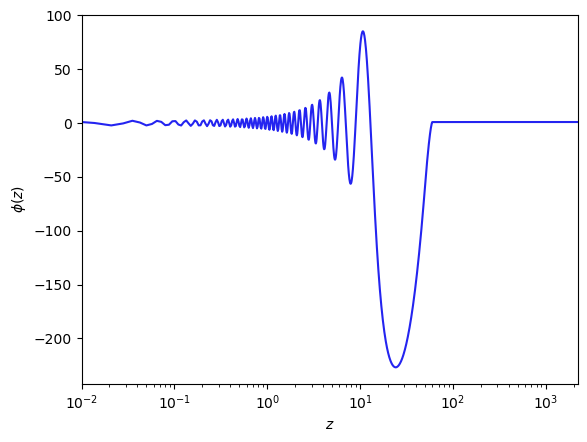

In [11]:
z = 1/a - 1
xscale('log')
xlim(0.01,2.2e3)
xlabel(r'$z$')
#ylim(-90,90)
ylabel(r'$\phi(z)$')
plot(z[::-1], phi[::-1])